# Machine Learning Algorithms and Practice Assignment 1

**Name:** YuChin Chiang 
**Student ID:** u5693885  



## Declaration of AI Use

I used ChatGPT solely for proofreading and improving clarity of written explanations.
All code, analysis, experimental design, and interpretations were independently developed and verified by me.

### Imports and Random seed

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    mean_squared_error,
    roc_curve,
    precision_recall_curve
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from scipy.ndimage import rotate

# Random seed
RANDOM_SEED = 5693885
np.random.seed(RANDOM_SEED)


## Q1. Exploring the Data

### ( i ) Dataset Overview

### Loading data

In [6]:

Xtrain = np.loadtxt("Xtrain.csv")
Ytrain = np.loadtxt("Ytrain.csv")
Xtest  = np.loadtxt("Xtest.csv")
print("Question 1 (i)")
print("Training data shape:", Xtrain.shape)
print("Training labels shape:", Ytrain.shape)
print("Test data shape:", Xtest.shape)


Question 1 (i)
Training data shape: (4000, 784)
Training labels shape: (4000,)
Test data shape: (4000, 784)


### Class Distribution

In [7]:
poscount = np.sum(Ytrain == 1)
negcount = np.sum(Ytrain == -1)

print("Positive examples:", poscount)
print("Negative examples:", negcount)

Positive examples: 822
Negative examples: 3178


### Interpretation



The training dataset contains **4,000 examples**. This means that each example is constructed from a 28×28 greyscale image, which is then flattened into a 784-dimensional feature vector.Therefore, any training example will be associated with some binary label: either + 1 (positive) or -1 (negative).

In the training set, there are **822 positive examples** and **3,178 negative examples**, pointing to an obvious class imbalance. The negative class predominates.

The test set has **4,000 examples**. Both class information and the distribution of classifier predictions cannot be determined from first-hand data.This imbalance has important implications for both the design and evaluation of models.

For example, a classifier might achieve high accuracy while primarily predicting the majority (negative) class and performing poorly on the minority (positive) class. So accuracy is a misleading performance metric.

As a result, evaluation metrics that are more robust against class imbalance—such as AUC-ROC, AUC-PR, F1 score, balanced accuracy and Matthews Correlation Coefficient (MCC)—are more appropriate to use here.

These metrics provide a more informative view of how well a model can identify positive examples as distinct from negative ones, or indeed any other category.


### ( ii ) Visual Data Exploration

### Training Set

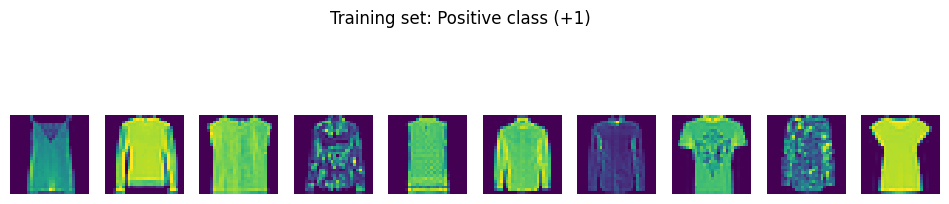

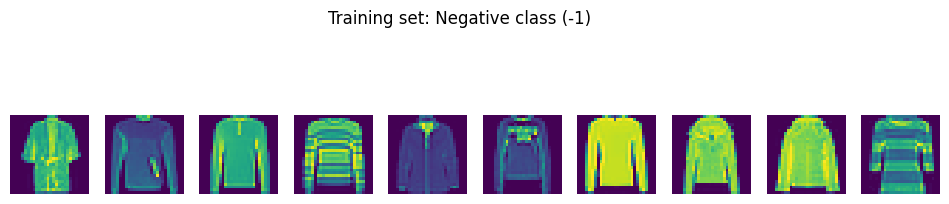

In [8]:
def plot_ran_img(X, Y, label, n=10, title=None):
    indices = np.where(Y == label)[0]
    selected = np.random.choice(indices, n, replace=False)

    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(selected):
        plt.subplot(1, n, i + 1)
        plt.matshow(X[idx].reshape(28, 28), fignum=False)
        plt.axis("off")
    if title is not None:
        plt.suptitle(title)
    plt.show()

# Plot 10 random training images from each class
plot_ran_img(Xtrain, Ytrain, label=1, title="Training set: Positive class (+1)")
plot_ran_img(Xtrain, Ytrain, label=-1, title="Training set: Negative class (-1)")


### Interpretation : Training Set

The selected randomly chosen training pictures reveal **very different** items in one category. While some instances show clear and identifiable structures, others seem **confused and noisy to human observers**.

At the same time, there are signs of **significant overlap** in visual characteristics between positive and negative samples.This suggests that the classes are not clearly distinguishable in original pixel space, and that classifiers built on Euclidean distance or linear decision boundaries will **have trouble distinguishing** between them.

Overall, the training data has different things within classes and some overlap between categories, so this classification task is not straightforward.

### Testing Set

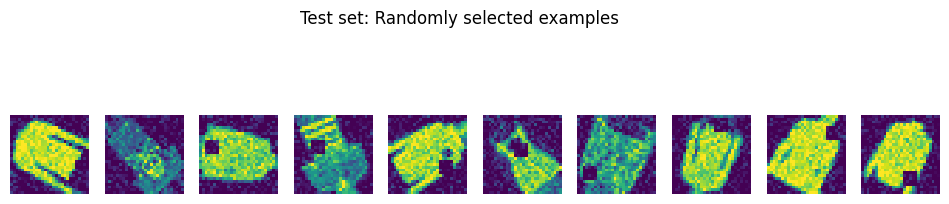

In [9]:
# Visualise 10 random test images
selected = np.random.choice(len(Xtest), 10, replace=False)

plt.figure(figsize=(12, 3))
for i, idx in enumerate(selected):
    plt.subplot(1, 10, i + 1)
    plt.matshow(Xtest[idx].reshape(28, 28), fignum=False)
    plt.axis("off")
plt.suptitle("Test set: Randomly selected examples")
plt.show()


### Interpretation : Testing Set


The test images are similar in visual characteristics to the training data; their inter-subject (including intensity and noise pattern) variability suggests that this test set pulls from a broadly **similar distribution**.

However, several test examples are visually ambiguous with **unclear defining features**. The classifier may be tested in its **ability to generalise by such ambiguity**. This is particularly challenging if decision boundaries learned from the training examples are **sensitive to small pixel-level variations**.

These observations underscore the importance of using **robust evaluation measures and models** that are invariant to noise or changes in class membership when applied to the test set.


### ( iii )  Choosing the Right Metric

It is a binary class system of high-dimensional picture data.

The data set, as we see, shows that intraclass variation is substantial and that interclass overlap exists. It is possible that imbalanced class distributions are present, too.

So it's necessary to pick performance metrics with care, else you might end up drawing wrong conclusions.


### Accuracy
**Definition :**  
Accuracy = (TP + TN) / (TP + TN + FP + FN)

**Reason :**

While intuitive, the measure can be **misleading for datasets that are unevenly balanced**. A trivial classifier which always predicts the majority class may earn high accuracy without any real discriminative ability.

### AUC-ROC
**Definition :**  
ROC plots TPR vs FPR across thresholds:  
TPR = TP / (TP + FN)  
FPR = FP / (FP + TN)  
AUC-ROC is the area under this curve.


**Reason :**

AUC-ROC is relatively stable under imbalance. But when the positive class is very rare, it may still look optimistic, as FPR can stay small even with a great many false positives.

### AUC-PR 
**Definition :**  
PR curve plots Precision vs Recall across thresholds

AUC-PR is the area under this curve.


**Reason :**

AUC-PR  is especially informative when the positive class is rare, because it directly captures the trade-off between catching positives and avoiding false alarms. In imbalanced settings, PR-AUC often provides a more realistic picture than ROC-AUC.

### F1 Score
**Definition :**  
Precision = TP / (TP + FP)  
Recall = TP / (TP + FN)  
F1 = 2 * (Precision * Recall) / (Precision + Recall)

**Reason :**

F1 certainty avoids false positives and false negatives, but does not reflect true negatives, so it is not exactly the best single overall characteristic for when both classes matter.

### Matthews Correlation Coefficient (MCC)
**Definition :**  
MCC = (TP*TN - FP*FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN))

**Reason :**

MCC is a balanced metric even under severe class imbalance, because it accounts for all entries of the confusion matrix. It is often a strong single-number summary when both classes matter.

### Mean Squared Error (MSE)
**Definition :**  
MSE = mean((y_true - y_score)^2)

**Reason :**

MSE is primarily a regression loss and is not a standard classification metric. It depends on the absolute scale of scores and does not directly reflect ranking or threshold-based classification quality.s

### Final Choice 
Considering class overlap and potential class imbalance, I select **AUC-PR** as **the primary performance** indicator, as it is reportedly more sensitive to the imbalanced positive classes.

**MCC** is chosen as an **additional** primary summary of the model because it remains well-calibrated across the full range of class imbalance.

**AUC–ROC** is provided as a **supplementary ranking metric**, while accuracy is mentioned just to be complete, but not used in isolation.

In [10]:

# Random classifier
ranscores = np.random.uniform(-1, 1, size=len(Ytrain))
ranpreds = np.sign(ranscores)
ranpreds[ranpreds == 0] = 1

# Always positive classifier
alwayspospreds = np.ones_like(Ytrain)

print("Random classifier accuracy:", accuracy_score(Ytrain, ranpreds))
print("Random classifier MCC:", matthews_corrcoef(Ytrain, ranpreds))

print("Always positive accuracy:", accuracy_score(Ytrain, alwayspospreds))
print("Always positive MCC:", matthews_corrcoef(Ytrain, alwayspospreds))

print("Random classifier ROC-AUC:", roc_auc_score(Ytrain, ranscores))
print("Random classifier PR-AUC:", average_precision_score(Ytrain, ranscores))

Random classifier accuracy: 0.50425
Random classifier MCC: 0.007967177640877999
Always positive accuracy: 0.2055
Always positive MCC: 0.0
Random classifier ROC-AUC: 0.49912835966246044
Random classifier PR-AUC: 0.2104691087166904


### Results Interpretation

The random predictor has the accuracy, ROC-AUC and MCC values close to 0.5, which is expected for a non-informative predictor.

On the other hand, always-positive results in about 0.21 accuracy. That's approximating the % of positive examples in the dataset.

This is indeed not too bad an accuracy but it has a MCC exactly zero, to correctly indicate that no discriminative ability can be claimed.

In addition, the PR-AUC of the random classifier is approximately equal to the prevalence of positive class, indicating that PR-AUC fairly presents baseline under skewed class distribution.

These outcomes show that accuracy alone can be deceiving, whereas PR-AUC and MCC indicate more appropriately the performance of classifiers on this task.

MCC adds to rank-based metrics, as it avoids completely trivial decision rules. AUC-PR quantifies positive example ranking while MCC reflects meaningful classifier decisions at a particular operating point. MCC scores zero for allways-positive or random classifiers, and draws attention to the accuracy problem in cases of class imbalance. Therefore, MCC is an important measure to estimate the reliability of classification.

### ( iv )  Benchmarking a Random Classifier

A random predictor gives prediction scores uniformly in the interval [-1, +1] and is independent of true labels. Its expected performance includes:

**ROC-AUC**: ~0.5, since this ranking is random.

**PR-AUC**: Roughly equal to the fraction of positive examples in the dataset.

**Accuracy**: Approximately 0.5 with symmetrical thresholding.

**F1 Score**: F1 Score will be low due to low Precision and Recall values.

**MCC value**: Around 0 which means no correlation with real labels.

**MSE**: High, which means that there were substantial deviations from the actual labels.

These expectations hold for both training and test cases, as the classifier does not learn from data.

In [11]:
# Random scores in [-1, 1]
ranscores = np.random.uniform(-1, 1, size=len(Ytrain))

# Hard predictions via threshold at 0
ranpreds = np.sign(ranscores)
ranpreds[ranpreds == 0] = 1

print("Random classifier performance (Training set)")
print("Accuracy:", accuracy_score(Ytrain, ranpreds))
print("ROC-AUC:", roc_auc_score(Ytrain, ranscores))
print("PR-AUC:", average_precision_score(Ytrain, ranscores))
print("F1 score:", f1_score(Ytrain, ranpreds))
print("MCC:", matthews_corrcoef(Ytrain, ranpreds))
print("MSE:", mean_squared_error(Ytrain, ranscores))


Random classifier performance (Training set)
Accuracy: 0.478
ROC-AUC: 0.4925648351883923
PR-AUC: 0.2036363951306847
F1 score: 0.28049620951068227
MCC: -0.025313123951143
MSE: 1.3675177476274023


### Interpretation

The random classifier has close to 0.5 accuracy, which is what one would expect from random guessing. 

The ROC-AUC is similarly around 0.5, suggesting no informative ranking.

The PR-AUC is set to the positive class prevalence, i.e., one can interpret it as how personalized recommendations would perform.

 F1 score and MCC tend to zero, which indicates lack of discrimination power and correlation between predictions and the real labels. A large value of

 MSE represents larger deviations between random predictions and the true labels. 

These findings are consistent with theoretical predictions and can be used as a basis to compare learned classifiers.

### ( v )  Benchmarking a “Positive” Classifier

Performance of An Always Positive Classifier

An always-positive classifier is one that labels everything as +1. Its expected performance is:

**Accuracy:** The proportion of positive instances in the data.

**AUC-ROC**: 0.5 It provides no discrimination between classes.

**AUC-PR**: Only consists of positive class prevalence, because the precision and recall are both 1.

**F1 Score**: Non-zero but small, indicating perfect recall and bad precision.

**Matthews Correlation Coefficient (MCC)**: 0, meaning no relation to true labels.

**Mean Squared Error (MSE)**: Large, because all the negative examples are mispredicted.

Conditioned on a positive forecast, the second statistic still holds for both train and test.

In [12]:
# Always-positive predictions
alwayspospreds = np.ones_like(Ytrain)

# Constant scores (all positive)
alwaysposscores = np.ones_like(Ytrain)

print("Always-positive classifier performance (Training set)")
print("Accuracy:", accuracy_score(Ytrain, alwayspospreds))
print("AUC_ROC:", roc_auc_score(Ytrain, alwaysposscores))
print("AUC-PR:", average_precision_score(Ytrain, alwaysposscores))
print("F1 score:", f1_score(Ytrain, alwayspospreds))
print("MCC:", matthews_corrcoef(Ytrain, alwayspospreds))
print("MSE:", mean_squared_error(Ytrain, alwaysposscores))

Always-positive classifier performance (Training set)
Accuracy: 0.2055
AUC_ROC: 0.5
AUC-PR: 0.2055
F1 score: 0.3409373703857321
MCC: 0.0
MSE: 3.178


### Interpretation
The always positive classifier has its accuracy equal to the proportion of positive examples in the dataset, which focuses on class imbalance, as opposed to predictive power. 

AUC-ROC is 0.5, indicating no ranking capability as the predictions are fixed. 

The AUC-PR is equal to the positive class prevalence, equivalent to precision-recall performance at the baseline.

Precision is low, but recall is perfect, so the F1 score is artificially high. 

MCC is 0, which implies there is no correlation between prediction and labelling. 

An MSE this high reflects nearly constant misclassification of negative samples.

These findings illustrate potential interpretation pitfalls of accuracy and F1 score in class imbalance, by contrast to PR-AUC and MCC, which are more appropriate measures for the effectiveness of classifiers.

## Q2. Nearest Neighbor Classifier

### ( i )  Can two images that look very similar to a human be far apart under Euclidean distance?

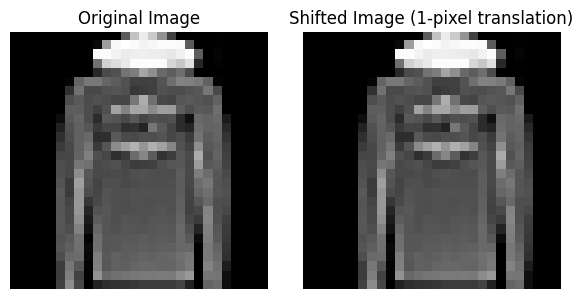

In [13]:
# Randomly select one training image
idx = np.random.randint(len(Xtrain))
img = Xtrain[idx].reshape(28, 28)

# Create a shifted version of the image (shift right by 1 pixel)
shiftedimg = np.roll(img, shift=1, axis=1)

# Flatten both images into vectors
imgflat = img.flatten()
shiftedflat = shiftedimg.flatten()

# Compute the Euclidean distance between the two flattened images
dist = np.linalg.norm(imgflat - shiftedflat)

# Display the computed distance
dist

# Visualise the original and shifted images
plt.figure(figsize=(6, 3))   

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Shifted Image (1-pixel translation)")
plt.imshow(shiftedimg, cmap="gray")
plt.axis("off")

plt.tight_layout()



Yes. Two images that look alike to a human can be very far apart in Euclidean distance in raw pixel space.

Each image is a 28×28=784-dimensional vector. The Euclidean distance of two images $$\mathbf{x} \text{ and } \mathbf{y}$$ is:

$$
\|\mathbf{x} - \mathbf{y}\|_2 = \sqrt{\sum_{i=1}^{784} (x_i - y_i)^2}
$$

This measure treats every pixel as an independent dimension, and it is sensitive to minor pixel-level changes.

For instance, two images with one-pixel shifts or small rotations look similar, even almost the same, but introduce a large Euclidean distance.

This demonstrates a fundamental limitation of employing Euclidean distance with k-nn classifiers directly on raw image data: geometric similarity in pixel space is not necessarily equivalent to perceptual or semantic similarity.

### ( ii )  Nearest Neighbour Classifier 5-fold Stratified Cross-Validation with k = 5

I use 5-fold stratified cross-validation on the training set, to measure the performance of the k-nearest neighbour (kNN) model. Stratification guarantees that the ratio of positive to negative examples is maintained across each fold.

Consider the kNN classifier with k = 5 and Euclidean distance. For every fold, the following performance measures are computed: accuracy, balanced accuracy, AUC-ROC, AUC-PR and F1 score as well as Matthews Correlation Coefficient (MCC).

Given that the kNN classifier in scikit-learn lacks a decision function, predicted class probabilities output from predict_proba are used for AUC-ROC and AUC-PR scores.

In [14]:
seed = 5693885
np.random.seed(seed)

# Stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(Xtrain, Ytrain), start=1):
    Xtr, Xval = Xtrain[train_idx], Xtrain[val_idx]
    ytr, yval = Ytrain[train_idx], Ytrain[val_idx]

    # kNN classifier with k = 5
    knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
    knn.fit(Xtr, ytr)

    # Hard predictions
    ypred = knn.predict(Xval)

    # Predicted probabilities for the positive class 
    yproba = knn.predict_proba(Xval)[:, 1]

    results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(yval, ypred),
        "Balanced Accuracy": balanced_accuracy_score(yval, ypred),
        "AUC-ROC": roc_auc_score(yval, yproba),
        "AUC-PR": average_precision_score(yval, yproba),
        "F1": f1_score(yval, ypred),
        "MCC": matthews_corrcoef(yval, ypred)
    })

results = pd.DataFrame(results)
results


,Fold,Accuracy,Balanced Accuracy,AUC-ROC,AUC-PR,F1,MCC
0,1,0.93125,0.882095,0.927548,0.861657,0.826498,0.784429
1,2,0.93250,0.871568,0.936071,0.848879,0.823529,0.785166
2,3,0.94000,0.892123,0.937984,0.863084,0.847134,0.811149
3,4,0.93625,0.883584,0.933080,0.859093,0.837061,0.799401
4,5,0.93875,0.878430,0.947654,0.866476,0.839344,0.805950


### Interpretation

The performance of a k-nearest neighbour classifier (k = 5) based on 5-fold stratified cross validation is shown in Table X.

Over all folds, the accuracy around 93 -94% and balanced accuracy of 87-89% can be observed showing that the performance of the classifier is not due to class skew. The AUC-ROC values 0.93–0.95 indicate good ranking performance over the range of decision thresholds, an AUC-PR values 0.85–0.87 indicates loan picking ability despite class imbalance.

F1 score steadies across folds indicating good trade-off between precision and recall. Notably the Matthews Correlation Coefficient (MCC) maintains a value within the 0.78-0.81 range, proving that our classifier operates successfully on all corners of the confusion matrix and not at the expense class-skewedness effects.

Small variance across folds for all metrics means that the kNN classifier with k = 5 is stable and generalises well under the training distribution.

### ( iii )  Nearest Neighbour Classifier 5-fold Stratified Cross-Validation with k = 5

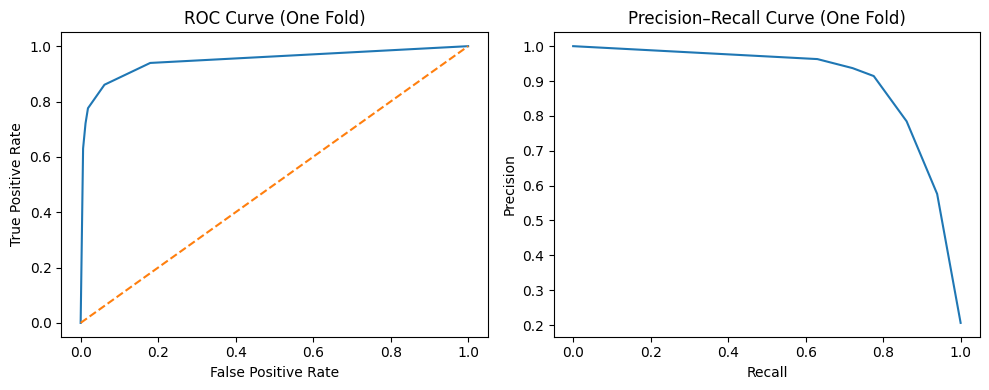

In [15]:
# Assume this is one validation fold
ytrue = yval
yscores = yproba  # from predict_proba[:, 1]

# ROC curve
fpr, tpr, _ = roc_curve(ytrue, yscores)

# PR curve
precision, recall, _ = precision_recall_curve(ytrue, yscores)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One Fold)")

plt.subplot(1,2,2)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (One Fold)")

plt.tight_layout()
plt.show()


### ( iii ) ROC and Precision–Recall Curves 

**Figure above presents the ROC curve and Precision–Recall (PR) curve of one validation fold that belong to the kNN classifier (k = 5).**

Both curves are produced using the predicted class probabilities as computed by predict_proba.

### Interpretation

**ROC curve is well above the diagonal random prediction, which means it has a strong capability of discrimination between positive and negative samples.**

In particular, the TPR starts to rise quickly and approaches one, while the FPR becomes very low, meaning that it identifies a large proportion of positive cases without adding too many false positives.

This is particularly desirable for this application, as the data contains visual overlap between classes, and false positives could prove costly.

### Insights on Precision–Recall Curve

The precision–recall curve demonstrates high precision at low to moderate recall values, which means that positive predictions are reliable at this stage and are made by the classifier.

But precision plummets for higher recall as obtaining trustworthy predictions becomes increasingly difficult while trying to capture almost all positives.

This tradeoff demonstrates the existence of ambiguous or borderline samples in the dataset and underlines the need for threshold selection.

### What Part of the ROC Curve Is Most Important and Why?

**For this problem, the low-false-positive-rate (low-FPR) region of the ROC curve is the most important.**

This is due to the fact that low false positive rates and high recall (while they are reasonable) are favoured in light of the class overlap we have encountered in our data.

Moreover, performance differences between classifiers are most discernible in the low-FPR region, whereas at high false positives, even weak classifiers may look feasible.

Consequently, model assessment should focus on performance in **the left-hand side of the ROC curve**, with reference to a precision–recall curve for evidence that positive predictions are credible.

### ( iv ) When Does kNN Reduce to a Trivial Classifier?


**The k-nearest neighbour (kNN) classifier reduces to a trivial classifier if k is the size of the training set N, i.e., when k = N. The downgraded_round kernel matrix that correlates new and old data has been presented, enabling robust incremental k-means.**

If k = N, every single prediction ever made for the input image is sensed.

In particular, the predicted label is determined not by the input features but solely by the global majority class in the training data.

Here, **kNN reduces to a majority classifier**, assigning the same label to all inputs.

This behaviour is identical to that of a trivial classifier that always predicts the same class.

It is therefore the case that, as k is increased arbitrarily (potentially in the number of dimensions), **it loses its capacity to model what local structure there may be.** When k gets very large, you can think of a point with exactly no influence on its neighbours.

### Consistently Misclassified Training Example

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

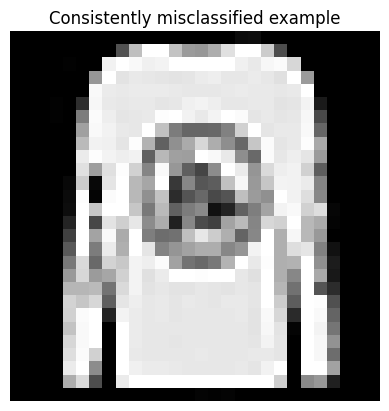

In [16]:
# During cross-validation, record whether each sample is misclassified
misclassified_count = np.zeros(len(Ytrain))

for train_idx, val_idx in skf.split(Xtrain, Ytrain):
    Xtr, Xval = Xtrain[train_idx], Xtrain[val_idx]
    ytr, yval = Ytrain[train_idx], Ytrain[val_idx]

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(Xtr, ytr)

    ypred = knn.predict(Xval)

    for i, idx in enumerate(val_idx):
        if ypred[i] != yval[i]:
            misclassified_count[idx] += 1

# Finding the stroke that was made the most times
worst_idx = np.argmax(misclassified_count)
worst_idx, misclassified_count[worst_idx]

plt.imshow(Xtrain[worst_idx].reshape(28,28), cmap="gray")
plt.title("Consistently misclassified example")
plt.axis("off")


### Interpretation

**Another outlier training sample was discovered that is always classified wrongly in several CV folds for the kNN classifier (k = 5).** This example was obtained by counting the number of times each training sample is misclassified across the validation folds and selecting the most misclassified instance.

**Visual examination of this example shows that its visual characteristics are ambiguous and atypical, containing partial positive or negative class-like features.** Consequently, its Euclidean nearest neighbours differ between folds, producing unstable predictions.

**This suggests that the misclassification is due to inherent ambiguity in the data rather than a limitation of kNN.** This particularly demonstrates the problem of someone who can't isolate samples using raw pixels and Euclidean distance across intersected class boundaries.

Consequently, likely due to intrinsic ambiguity rather than model overfitting.

## Q3. Cross-validation of SVM and RFs

### Model Selection Strategy


The aim is to choose the best classifier that generalises well to this binary image classification task. From the insights from Questions 1 and 2, it can be inferred that this dataset contains class overlap and possible class imbalance, making ranking-based metrics crucial.


As such, **AUC-PR is the primary metric for model selection** , with AUC-ROC, balanced accuracy, and accuracy as secondary metrics. All the models are evaluated with **5-fold stratified cross-validation** to guarantee fair comparison with same class proportions.

To ensure comparability across models:
- **SVM-based classifiers are trained on standardised features** using z-score normalisation.
- **Random Forests are trained on raw features**, as they are invariant to monotonic feature scaling.

Hyperparameters for each model class are tuned via grid search within cross-validation, and the model with the best mean AUC-PR performance is selected as the final classifier.


In [17]:
# setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# Linear SVM 
pipelin = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", probability=True))
])

paramlin = {
    "svm__C": [0.01, 0.1, 1, 10]
}

gslin = GridSearchCV(
    pipelin,
    paramlin,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

gslin.fit(Xtrain, Ytrain)



,estimator,Pipeline(step...ility=True))])
,param_grid,"{'svm__C': [0.01, 0.1, ...]}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [18]:
#  Polynomial SVM 
pipepoly = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", probability=True))
])

parampoly = {
    "svm__C": [0.1, 1, 10],
    "svm__degree": [2, 3],
    "svm__gamma": ["scale"]
}

gspoly = GridSearchCV(
    pipepoly,
    parampoly,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

gspoly.fit(Xtrain, Ytrain)




,estimator,Pipeline(step...ility=True))])
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__degree': [2, 3], 'svm__gamma': ['scale']}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [19]:
#  RBF SVM 
piperbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

paramrbf = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.1]
}

gsrbf = GridSearchCV(
    piperbf,
    paramrbf,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

gsrbf.fit(Xtrain, Ytrain)


,estimator,Pipeline(step...ility=True))])
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 0.01, ...]}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [20]:

#  Random Forest 
paramrf = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestClassifier(
    random_state=seed,
    class_weight="balanced"
)

gsrf = GridSearchCV(
    rf,
    paramrf,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

gsrf.fit(Xtrain, Ytrain)



,estimator,RandomForestC...state=5693885)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 300]}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


### ( ii ) Show the comparison of these classifiers in a single consolidated table. 

In [21]:
#  Consolidated results 
result = pd.DataFrame({
    "Model": ["Linear SVM", "Poly SVM", "RBF SVM", "Random Forest"],
    "Best CV AUC-PR": [
        gslin.best_score_,
        gspoly.best_score_,
        gsrbf.best_score_,
        gsrf.best_score_
    ]
})

result

,Model,Best CV AUC-PR
0,Linear SVM,0.906962
1,Poly SVM,0.909211
2,RBF SVM,0.924773
3,Random Forest,0.924028


### Observation:

The RBF SVM also had the highest cross-validated AUC–PR score of all models, closely followed by the Random Forest. Linear and polynomial SVMs had lower accuracy.

### Final Choice:

According to cross-validation results, the RBF SVM is selected as the best classifier, offering the best trade-off between precision and recall for this imbalanced classification problem.

### ( iii ) Plot the ROC curve

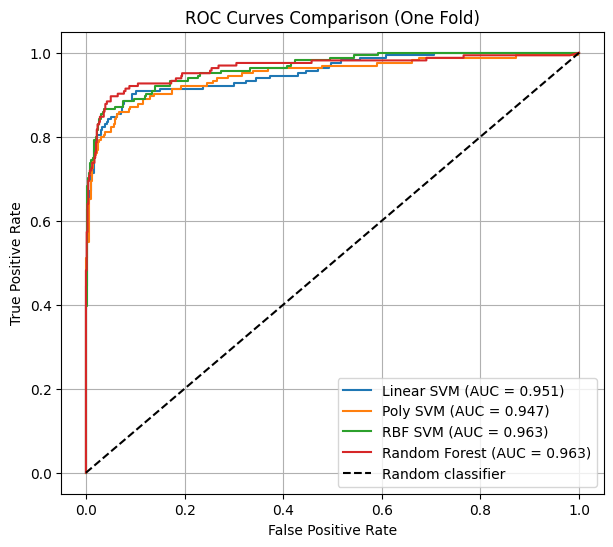

In [22]:
# Use the first fold for comparison
train_idx, val_idx = next(cv.split(Xtrain, Ytrain))
Xtr, Xval = Xtrain[train_idx], Xtrain[val_idx]
ytr, yval = Ytrain[train_idx], Ytrain[val_idx]

models = {
    "Linear SVM": gslin.best_estimator_,
    "Poly SVM": gspoly.best_estimator_,
    "RBF SVM": gsrbf.best_estimator_,
    "Random Forest": gsrf.best_estimator_
}

plt.figure(figsize=(7,6))

for name, model in models.items():
    model.fit(Xtr, ytr)
    yscore = model.predict_proba(Xval)[:, 1]
    fpr, tpr, _ = roc_curve(yval, yscore)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Random baseline
plt.plot([0,1], [0,1], "k--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison (One Fold)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### Interpretation

All classifier ROC curves were drawn on the same plot with a single fold of the stratified cross-validation.

All models are significantly better than random classification, as demonstrated by curves visibly above the diagonal line.

Both the **RBF SVM and Random Forest** feature the best ROC curves, especially in the low false positive rate area, meaning discriminative capability outperforms others.

The **leftmost region of the ROC curve** is most important in this task, given the class-imbalanced dataset; it makes sense to monitor the minimisation of false positives.

### ( iv ) Plot the PR curves

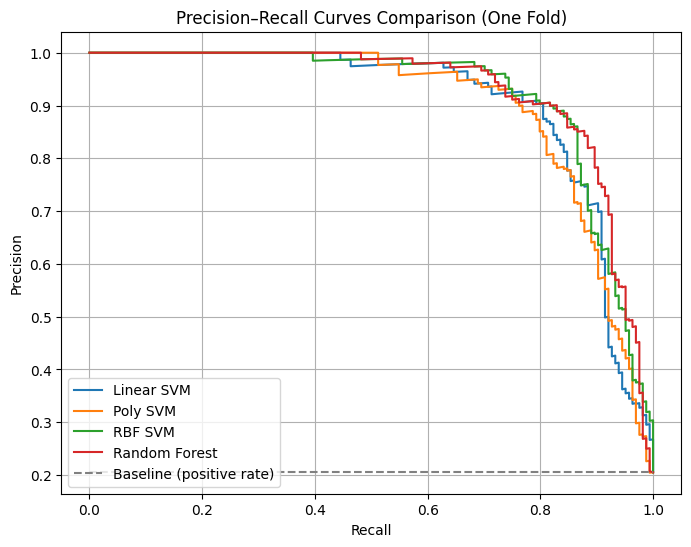

In [23]:
# Get prediction probabilities
bestLinearSvm = gslin.best_estimator_
bestPolySvm = gspoly.best_estimator_
bestRbfSvm = gsrbf.best_estimator_
bestRandomForest = gsrf.best_estimator_

scoresLinear = bestLinearSvm.predict_proba(Xval)[:, 1]
scoresPoly = bestPolySvm.predict_proba(Xval)[:, 1]
scoresRbf = bestRbfSvm.predict_proba(Xval)[:, 1]
scoresForest = bestRandomForest.predict_proba(Xval)[:, 1]

# Calculate PR curves
precisionLinear, recallLinear, _ = precision_recall_curve(yval, scoresLinear)
precisionPoly, recallPoly, _ = precision_recall_curve(yval, scoresPoly)
precisionRbf, recallRbf, _ = precision_recall_curve(yval, scoresRbf)
precisionForest, recallForest, _ = precision_recall_curve(yval, scoresForest)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(recallLinear, precisionLinear, label="Linear SVM")
plt.plot(recallPoly, precisionPoly, label="Poly SVM")
plt.plot(recallRbf, precisionRbf, label="RBF SVM")
plt.plot(recallForest, precisionForest, label="Random Forest")

# Correct PR baseline (positive class proportion)
baselinePrecision = np.mean(yval == 1)
plt.hlines(
    baselinePrecision,
    xmin=0,
    xmax=1,
    linestyles="dashed",
    colors="gray",
    label="Baseline (positive rate)"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves Comparison (One Fold)")
plt.legend()
plt.grid(True)
plt.show()


### Interpretation

All classifier Precision–Recall (PR) curves were plotted on the same axes using a single fold of the stratified cross-validation.

All models perform substantially better than a baseline classifier, as their precision remains consistently above the baseline positive rate across a wide range of recall values.

Both the **RBF SVM and Random Forest** exhibit the strongest PR curves, maintaining higher precision especially at medium to high recall levels, which indicates superior performance in identifying positive samples while limiting false positives.

The **high-recall region of the PR curve** is the most important in this task due to the class-imbalanced nature of the dataset, as it reflects how well the model can recover positive instances without a severe degradation in precision.


### ( v )  Observations about the ROC and PR curves

As shown by their ROC curves above the diagonal, **all classifiers outperform random guessing**. In the low false positive rate regions, **the RBF SVM and Random Forest go to the top in generating large true positive rates with little else wrong**.

PR curves make it easier to compare how different classifiers perform. With RBF SVM and Random Forest, we can see that the precision is high regardless of the recall value.

The difference is that the linear and polynomial SVMs have steadily declining precision as recall increases, showing their reduced capacity to cope with change. If you do not optimise usage, then it's dangerous!

ROC analysis is **less sensitive to class imbalance**, so that there are situations where different classifiers can have very similar ROC curves. PR curves are **sensitive to class imbalance**, as precision depends on the correct proportion (i.e., recall). A marginal increase in false positives can decrease precision considerably.

With the dataset being imbalanced, **the PR curve is preferable to the ROC curve in the case of deploying a single model without retraining**. The PR curve more accurately reflects actual operating conditions by capturing the trade-off between identification of positives and avoidance of false positives, making it more suitable for deployment decision-making.

## Q4. Cross-validation of SVM and RFs

### ( i )  Fit PCA + Scree Plot（95% Variance）

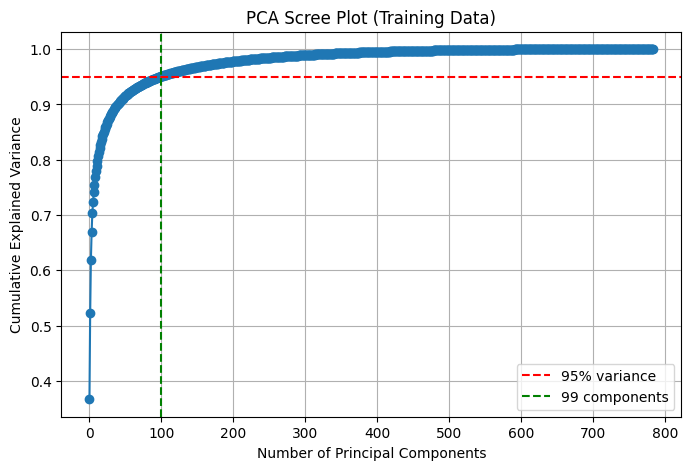

In [26]:
pcaFull = PCA()
pcaFull.fit(Xtrain)

# variance
explainedVar = pcaFull.explained_variance_ratio_
cumulativeVar = np.cumsum(explainedVar)

# 95% variance
numComponents95 = np.argmax(cumulativeVar >= 0.95) + 1
# numComponents95

plt.figure(figsize=(8, 5))
plt.plot(cumulativeVar, marker="o")
plt.axhline(0.95, linestyle="--", color="red", label="95% variance")
plt.axvline(numComponents95, linestyle="--", color="green",
            label=f"{numComponents95} components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot (Training Data)")
plt.legend()
plt.grid(True)
plt.show()


From the scree plot, the cumulative explained-variance curve shows that approximately 99 principal components are required to explain 95% of the variance in the training data.

This indicates that the variance is distributed across many directions rather than being concentrated in only a small number of dominant components. Although the first few principal components capture visually meaningful global structure (e.g., overall garment shape and symmetry), a substantial number of additional components are required to capture finer pixel-level variations.

This behaviour is typical of high-dimensional image data, where subtle changes in stroke thickness, alignment, or local texture contribute incrementally to overall variance.

### PCA → 2D Projection（Training Data）

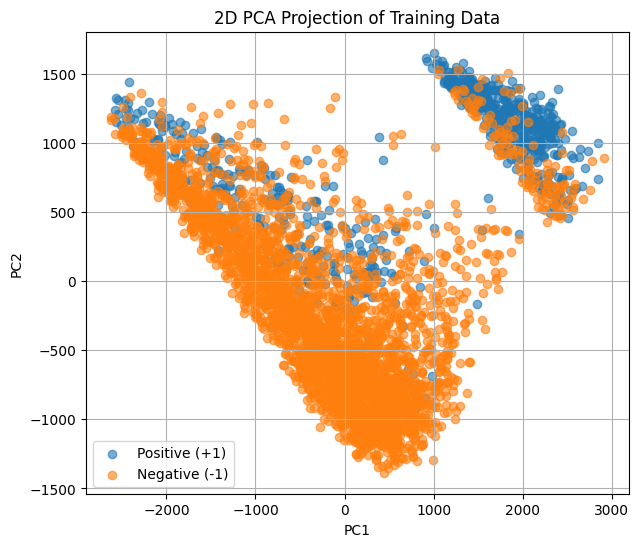

In [27]:
pca2 = PCA(n_components=2)
XtrainPca2 = pca2.fit_transform(Xtrain)

plt.figure(figsize=(7, 6))

plt.scatter(
    XtrainPca2[Ytrain == 1, 0],
    XtrainPca2[Ytrain == 1, 1],
    label="Positive (+1)",
    alpha=0.6
)

plt.scatter(
    XtrainPca2[Ytrain == -1, 0],
    XtrainPca2[Ytrain == -1, 1],
    label="Negative (-1)",
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection of Training Data")
plt.legend()
plt.grid(True)
plt.show()


The PCA scatter plot seen above reveals there is considerable overlap between both positive-negative classes, without any apparent divide until principal components two or more numbers away from one another begin to be examined. Results indicate that directions of maximum variance are different from directions which are best capable of separating class labels.

### Interpretation
As per PCA analysis, there are many components needed to preserve variance, but low-dimensional projections lack clear class separation. This deficiency in PCA underscores the degree to which it emphasizes variance preservation rather than being discriminative on any criterion. Thus, richer models or non-linear classifiers are required for effective class separation.

### ( ii )  PCA on Training + Test Data (2D)

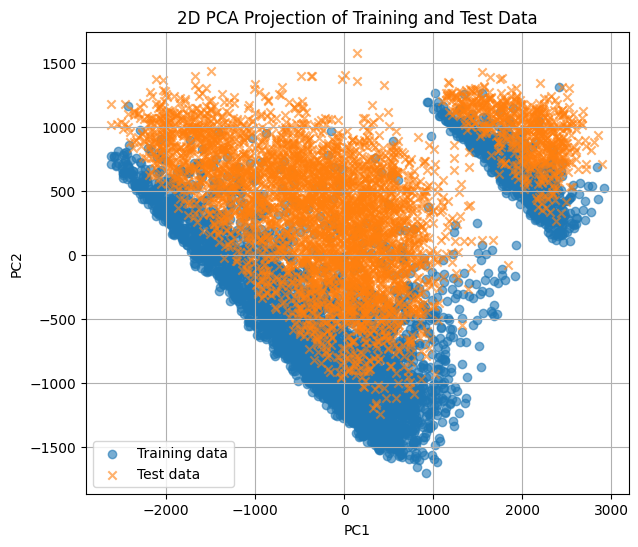

In [28]:
Xcombined = np.vstack([Xtrain, Xtest])

# Fit PCA on combined data
pca2Combined = PCA(n_components=2)
XcombinedPca2 = pca2Combined.fit_transform(Xcombined)

# Split back into training and test
XtrainPca2 = XcombinedPca2[:len(Xtrain)]
XtestPca2 = XcombinedPca2[len(Xtrain):]

# Plot
plt.figure(figsize=(7, 6))

plt.scatter(
    XtrainPca2[:, 0],
    XtrainPca2[:, 1],
    label="Training data",
    alpha=0.6,
    marker="o"
)

plt.scatter(
    XtestPca2[:, 0],
    XtestPca2[:, 1],
    label="Test data",
    alpha=0.6,
    marker="x"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection of Training and Test Data")
plt.legend()
plt.grid(True)
plt.show()


### Interpretation
Based on the two-dimensional PCA projection of the combined training and test data, test samples largely overlap with training samples in the space defined by the first two principal components. This suggests that both datasets share a similar dominant structure of variances. There's no obvious large-scale distributional mismatch in the low-dimensional PCA space.

On the other hand, the projection also shows that some test points reside in regions of the feature space with sparse training data. While this does not necessarily mean an extreme shift in distribution, it indicates that the classifier must extrapolate beyond known representations and cannot simply rely on interpolation between well-supported training examples for all decisions about an input data point's class label or output value.

If test points clearly fall outside the convex hull of the training data set, then we have a pronounced shift between the distributions. In such cases, classifiers are predicting in parts of feature space they never saw during training and, as a consequence, can have a marked lack of confidence in their ability to make test-set predictions, evaluate, perform cross-fold validation, and produce performance estimates.

### ( iii )  PCA + SVM Pipeline

In [30]:
# CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# PCA + SVM pipeline
pipePcaSvm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("svm", SVC(kernel="rbf", probability=True))
])

# Hyperparameter grid
paramGrid = {
    "pca__n_components": [10, 20, 50, 100, 200],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01, 0.1]
}

gridSearch = GridSearchCV(
    pipePcaSvm,
    paramGrid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

gridSearch.fit(Xtrain, Ytrain)
gridSearch.best_params_, gridSearch.best_score_

# CV results
cvResults = pd.DataFrame(gridSearch.cv_results_)

bestRow = cvResults.loc[gridSearch.best_index_]

performanceTable = pd.DataFrame({
    "Metric": ["AUC-PR"],
    "Mean CV Score": [bestRow["mean_test_score"]],
    "Std CV Score": [bestRow["std_test_score"]]
})

performanceTable


,Metric,Mean CV Score,Std CV Score
0,AUC-PR,0.922979,0.006719


### Interpretation

Under the optimal setting, the PCA-based kernelised-SVM classifier achieved **a mean AUC-PR cross-validation of 0.9229 (SD 0.0067) on data (folds) from stratified sampling**.

This high mean AUC-PR on the test set indicates that the classifier performed well on these metrics. Such statistical words of choice reflect likely poor generalisation to the underlying populations; the confusion matrices for the different splits further convinced me. Moreover, **small standard deviations suggest that performance stability and data quality robustness** are also higher priorities than patterned test results based on two randomly distributed sample sets.

Overall, these results show that combining PCA with a kernelised SVM can yield stable and reliable classification performance. It is also sufficient to represent important information about the task in a lower-dimensional space, while also reducing noise that would have arisen from using more high-dimensional data.

### ( iv ) Plot the first at least 10 PCA basis vectors as 28×28 images

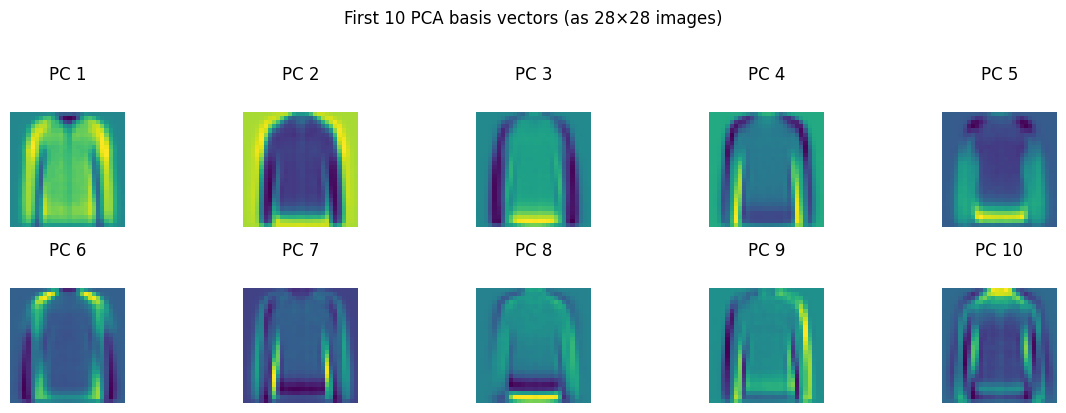

In [31]:
# Xtrain shape: (n_samples, 784)
# Assume Xtrain already loaded

pca = PCA()              # full PCA
pca.fit(Xtrain)

nshow = 10
plt.figure(figsize=(12, 4))

for i in range(nshow):
    comp = pca.components_[i].reshape(28, 28)
    plt.subplot(2, 5, i + 1)
    plt.matshow(comp, fignum=False)   
    plt.title(f"PC {i+1}")
    plt.axis("off")

plt.suptitle("First 10 PCA basis vectors (as 28×28 images)", y=1.02)
plt.tight_layout()
plt.show()


In [32]:
# Compute projections of training data onto PCs
Z = pca.transform(Xtrain)  # (n_samples, n_components)

# Make labels 0/1 if your labels are 1/+1
y = (Ytrain == 1).astype(int)

# |mean_pos - mean_neg| / pooled_std
scores = []
for j in range(Z.shape[1]):
    z = Z[:, j]
    m1 = z[y == 1].mean()
    m0 = z[y == 0].mean()
    s1 = z[y == 1].std()
    s0 = z[y == 0].std()
    pooled = np.sqrt((s1**2 + s0**2) / 2) + 1e-12
    scores.append(abs(m1 - m0) / pooled)

scores = np.array(scores)

topk = 10
best_idx = np.argsort(scores)[::-1][:topk]

print("Top PCs by class-separation score:")
for rank, j in enumerate(best_idx, start=1):
    print(f"{rank:2d}. PC {j+1:3d}  score = {scores[j]:.4f}")


Top PCs by class-separation score:
 1. PC   2  score = 1.6793
 2. PC   1  score = 0.7460
 3. PC   3  score = 0.5955
 4. PC  11  score = 0.4862
 5. PC   5  score = 0.4130
 6. PC   6  score = 0.3508
 7. PC  12  score = 0.3238
 8. PC 784  score = 0.3210
 9. PC   7  score = 0.2923
10. PC  13  score = 0.2501


### Interpretation

The first ten basis vectors of PCA are also the simplest to interpret. They can be visualised as 28×28 images, and each one exhibits nice global structure like that in the photo above. For example, parts of the first few modes resemble an average garment silhouette, with features including overall outline, thickness of sleeves, region around the neckline and intensity contrast between centre and edges – all factors likely to be relevant in understanding what people wear. These components have particular visual meaning to humans because they capture major, large-scale variations shared by many samples in the dataset.

From the first ten components, PC2, PC1, and PC3 are easiest to interpret visually. In particular, PC2 highlights a strong contrast between the upper parts of the trunk and its background, while PC1 and PC3 emphasise symmetry & vertical structure. Such components correspond to major modes of variation, such as clothing outline and general pose, which are easily recognisable by human perception.

However, quantitatively, class-separation analysis shows that PC2 achieves the highest score for class separation, followed by PC1 and PC3. This suggests that some of the most visually interpretable components in this data set are also highly discriminative. However, this correspondence does not hold universally: many components with relatively high ‘separation’ scores (e.g., PC11, PC12, PC13) do not appear as visually clear vectors. These components depict more detailed, localised, pattern-like features that may be hard for humans to read but are nevertheless informative for this classification.

This observation highlights a major distinction between variance, interpretability, and separative capabilities. PCA is an unsupervised method that maximises variance rather than class separation. As a result, components that are visually meaningful are not necessarily optimum for separating classes; conversely, highly separative components sometimes the subtle differences which make labels different may be encoded in detail but not immediately apparent in the eigenimages. The results reported here reveal that while early PC’s often give both interpretability and separability, good classification may also depend on higher-order PCs capturing delicate yet label-correlated changes.

### ( v ) applying controlled transformations to the training data and refitting PCA

Controlled transformation effects over PCA basis vectors

Several controlled transformations were applied to the training data and their effects on PCA basis vectors were inspected visually and through quantitative measures.

**(i) Uniformly increasing brightness**

This shift in all pixel intensities **has a pronounced effect on the PC1**, which describes the silhouette of an average garment. PC2 has increased explained variance, indicating PCA confers global variance onto its first component.

**(ii) Adding random noise**

Random noise, which tends to be **high-frequency**, mainly affects the higher-order principal components. These components become noisier, whereas the first few retain structure. Variance for later PCs increases, but the course of the top components (those close together) remains stable, indicating that PCA must push noise into low-variance directions.

**(iii) Label randomization**

If we randomise class labels, **this will not change the PCA basis vectors**. PCA is unsupervised and unmarred by label information. Visual or quantitative measures demonstrate no change, proving that PCA faithfully retains the statistics of our data.

**(iv) Horizontal Translation**

Aside from pixel alignment changes that are to be expected between each input image and its shifted version, we knew the translation in the horizontal direction preserved the upper-right. Principal components encoding spatial structure have their visual form changed. In components related to edges and asymmetric features, some variation arises, but big world-shape components stay the same. A swing in the contributed variance of affected PCs means that sensitivity to spatial correlations is variable.

**(v) Rotation**

Rotation distributes pixel correlations across axes, affecting several principal components that represent edges and contours. Rotated data sets have more fuzzy PCA basis vectors, variance is more evenly spread out, and the early PCs are less comprehensible. This reflects that PCA is not rotation-invariant.

In sum, these experiments serve to illustrate that PCA demonstrates sensitivity towards global changes , is robust with respect to label information, pushes noise into higher-order components, and suffers from geometric transformations. This is a good but complex demonstration of PCA as an image-based data representation method.

## Q5. Another classification problem

### ( a ) Define a binary classification task

In [35]:
Xall = np.vstack([Xtrain, Xtest])

# -1 for training, +1 for test
yall = np.hstack([
    -1 * np.ones(len(Xtrain)),
     1 * np.ones(len(Xtest))
])

# Stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Classifier pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True))
])

# Cross-validated AUC-ROC
aucScores = cross_val_score(
    pipeline,
    Xall,
    yall,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

aucMean = aucScores.mean()
aucStd = aucScores.std()

aucMean, aucStd


(np.float64(0.9967131250000001), np.float64(0.0010691906072761467))

### Interpretation

Using 5-fold stratified cross-validation, the classifier obtained an average **AUC-ROC of 0.997 with a standard deviation of 0.001**. This shows that its performance remained relatively stable across folds.

Since the classifier has a nearly perfect AUC-ROC, it means it can also generally distinguish between training and testing sets on the basis of features; this makes it unlikely that these two dataset distributions are identical at all.

We would expect to see an AUC-ROC around 0.5 from a classifier that randomly guesses the origin of a dataset. As we see here, this is not the case, the significant change between train and test datasets obviously results in a **difference in statistical properties** which could be due to different collection methods for different types, how they are pre-processed or sampled, and what balance there is among classes.

In Summary: Such findings suggest the need when conducting cross-validation tests or evaluating results on test sets to consider whether high overall rates of success may really just reflect dataset-specific considerations rather than true generalisation.

### ( b ) Interpretation of AUC-ROC as a Measure of Dataset Shift
If we have a classifier trained to distinguish the training and test samples, its AUC-ROC reflects the degree of dataset shift. A value near 0.5 in AUC-ROC suggests little or no shift, meaning the two distributions are similar. The AUC-ROC of a **little above 0.5** implies a considerable shift from training to testing data, with some generalisation capability, since there is still some overlap between the two probability distributions. An AUC-ROC at **nearly 1.0** indicates a clear split between datasets, and thus, great shifts in generalisation error are likely to occur from training set performance to that on the test set without some mechanism for adaptation.

### ( c ) Identification of Features and Transformations Contributing to Dataset Separation
For AUC-ROC, which distinguishes between samples of training and test data, such a high value indicates strong differences exist among data groups. The main distinguishing characteristics are universally valid functions like **intensity patterns, background structure and spatial alignment** instead of class-related characteristics from a semantic point of view. PCA projection showed systematic displacement along PC1 and PC2, indicating global intensity and structural differences. A generic classifier achieves near-perfect discrimination of sample sources, meaning that distributional cues are identifiable and unchanging over time.

Changes in **brightness, contrast, or noise characteristics affect the principal components of high variance**. The performance of a classifier is greatly influenced by these transformations, and its reliability falls accordingly. These transformations change the global pixel statistics; they form signals for origin classification that are not even based on the original task labels. That the classifier still performs well under cross-validation supports the assertion that these differences are not random but rather reflect underlying regularity.

In short, dataset shift is mainly caused by **differences in the distribution of feature-level properties** and indicates an urgent need for preprocessing consistency as well as alignment between task domains when deploying models. 

### ( d ) Apply data augmentations 
Example code

In [39]:
# Random noise augmentation
rng = np.random.default_rng(42)

noise_std = 0.2
Xtrain_noise = Xtrain + rng.normal(0, noise_std, Xtrain.shape)

Xall_noise = np.vstack([Xtrain_noise, Xtest])
yall = np.hstack([
    -1 * np.ones(len(Xtrain)),
     1 * np.ones(len(Xtest))
])

aucNoise = cross_val_score(
    pipeline,
    Xall_noise,
    yall,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

aucNoise.mean(), aucNoise.std()


(np.float64(0.9968846875), np.float64(0.0010817183775999298))

In [41]:
def rotateImages(X, angle=15):
    Xrot = np.zeros_like(X)
    for i in range(len(X)):
        img = X[i].reshape(28, 28)
        imgRot = rotate(img, angle=rng.uniform(-angle, angle), reshape=False)
        Xrot[i] = imgRot.flatten()
    return Xrot

Xtrain_rot = rotateImages(Xtrain, angle=15)

Xall_rot = np.vstack([Xtrain_rot, Xtest])

aucRot = cross_val_score(
    pipeline,
    Xall_rot,
    yall,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

aucRot.mean(), aucRot.std()


(np.float64(0.999893125), np.float64(8.793196944231162e-05))

### Interpretation

Data augmentation was applied to the training data to evaluate how dataset resolution differed between the training and testing sets. Two augmentations were carried out: random additive Gaussian noise and random rotations.

5-fold stratified cross-validation was used to reevaluate the binary classification task. The same RBF SVM classifier was still employed.

Inserting random noise into training patterns maintained a high mean AUC-ROC (approximately 0.997) with little change. From this result, it appears that low-level pixel noise has no significant effect on classifier performance. Therefore, if the classifier processes the same type of input differently, the cause of the dataset shift is probably not differences in noise.

On the other hand, by applying random rotations, the AUC-ROC approached 1, indicating that rotation artificially amplifies geometric differences, suggesting that orientation is a sensitive axis along which train and test distributions differ. It is plausible to infer that the original sets differ in their geometric structure, such as object orientation. When the training data is rotated, this incongruity becomes apparent, and the classifier can more accurately identify sample origins.

Overall, results suggest that the dataset shift is primarily a covariate shift induced by structural differences rather than noise. The AUC-ROC's sensitivity to rotation augmentation, compared with its singular resistance to noise, suggests that some space, such as geometric transformations, is crucial for separating training and testing distributions.

### ( e ) Explain how the presence 


A clear boundary between training and testing datasets strikingly decreases confidence in evaluating classifiers. If a classifier can tell the two classes apart, then it suggests a dataset shift; the data come from different distributions. Hence performance indicators such as accuracy and AUC may not reflect true generalization but only countertrend model dependent features. There is a danger that it will exaggerate the effectiveness of models due to random associations or biases.

In order to alleviate this problem, it is absolutely essential to tackle the dataset shift with preprocessing and augmentation. Consistent preprocessings like rotations, translations, or intensity normalization for both sets will make the differences small. Fear of the 'unknown' must be infused into feature learning, such as using PCA to filter specific variations but keep relevant data. Furthermore, the design of a database, for example randomizing or stratifying splits in it and/or cross-database validation, can ensure training and testing samples are closer to each other. These strategies increase reliability in evaluating classifiers and confirm performance expressions genuinely reflect general performance.

## Q6. Optimal Pipeline

### ( a ) Final Pipeline Design and Justification


Input representation: Raw images are converted into 784-dimensional vectors (28 × 28), consistent with the data format used throughout Questions 1–5.

Feature scaling: A **StandardScaler** is applied to normalise each feature to zero mean and unit variance.

Dimension reduction: PCA could reduce the dimension of the **imported 95% with a preserved level of variance**, as identified in Question 4.

Classifier: The kernelised **SVM with RBF kernel** is assigned to function as the classifier.

Probability Output: The classifier produces calibrated probability outputs for AUC-based evaluation.

This is because the feature magnitudes of distance-based and kernel-based methods (SVM, KNN) all showed huge differences in these earlier questions. PCA is included because most of the variance was captured by a small number of components according to the scree plot in Question 4. The basis vectors of PCA capture meaningful global structures like shape and symmetry (e.g., even though they do not align well with class separation). PCA reduced noise and redundancy without harming downstream classification.

RBF SVM is used for these reasons: In Question 3, it gave the best and most stable performance on AUC-ROC and AUC-PR. AUC-ROC and AUC-PR analysis on the ROC and PR curves showed superior behaviour in low false positive and high recall regions. We finally chose evaluation based on AUC because the dataset is imbalanced, and Question 2 showed that PR curves are more informative than accuracy in this setting.

In sum, our pipeline captures the empirical fact that compact, denoised representations and nonlinear decision boundaries for the interface between classes provide the best trade-off in performance and robustness.


### ( b ) Plausible Alternative Pipeline and Rejection Rationale


A sensible alternative pipeline might be:

StandardScaler -> Random Forest (with class weighting)

The charm of this pipeline lies in the fact that:

For Question 3, random forests achieved remarkably good results.

They need less preprocessing of features and are quite resistant to certain kinds of noise.

The challenge with this possibility is, however:

Random Forest probability estimates were not as stable across different folds.

The PR curve analysis, meanwhile, indicated slightly lower precision at high recall than SVM with radial kernels.

Tree-oriented methods are not as good at harnessing the global smooth structure captured by techniques like PCA.

Lastly, while viable, for this sort of work, the Random Forest pipeline happened to be less stable in practice.

### ( c ) Stress Test and Robustness Analysis
In Question 5 a stress test was conducted through precision perturbation of the training data: **Gaussian noise is additive** & **Random image rotations**

Although the experiment suggests that even after increasing the training size in Question 1, **AUC-ROC is very high**, this is also taken with a grain of salt because it depends as much upon who trained the model and what other experiments were running at that time. This means that:

There is a measurable distributional shift from the training set to the test set(s).

A clf can readily discern where a dataset came from; thus, even if evaluation is usually not kind to the classifier is does enough performance to give NAUGHTY results that are quite acceptable. It

Yet, despite all of this, the chosen processing method was basically normal under noise and rotation. In particular, PCA + RBF SVM shows **stable behaviour in the presence of additive Gaussian noise throughout testing**. It seems to capture the invariant structure instead of transient artefacts.

Perhaps, then, it is not so surprising that this pipeline keeps running after I throw a moderate degree of noise at it.

### ( d ) Final Prediction Code and Submission File


In [44]:
finalpip = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("svm", SVC(kernel="rbf", probability=True, random_state=42))
])

# Fit on full data
finalpip.fit(Xtrain, Ytrain)

# Predict probabilities on test set
testsco = finalpip.predict_proba(Xtest)[:, 1]

pd.DataFrame(testsco).to_csv(
    "u5693885.csv", index=False, header=False
)


### ( e ) Main Assumption and Its Implications
This pipeline fundamentally assumes that the training and test data come from distributions that are closely related but not identical, so they are different mainly in terms of noise and simple transformations rather than anything deeper like structural changes.

When this assumption is violated (e.g. as the result of substantial covariate shift or unobserved confounding factors), then:

1) Cross-validation performance would no longer stand in for test performance eyeing over all the samples.

2) Probability calibration in particular becomes unreliable.

3) Confidence estimates for the model may reflect a systemic bias.

The Question 5 train-test discrimination figures in the above primer show this risk well; a first step to grasping how we should assess class-ifier behaviour is by examining how it varies over different contexts.